## ElasticFDSG — 3D Demo

This notebook walks through a complete 3D elastic wave simulation using **ElasticFDSG**.
It covers:

1. Building a layered 3D velocity model with Tsvankin (orthorhombic) parameters
2. Configuring and running the simulation
3. Visualising wavefield snapshots (XY/XZ/YZ planes), geophone records, and DAS data

---

**Requirements**
- `ElasticFDSG`, `GLMakie` installed in the project environment

In [ ]:
using ElasticFDSG
using GLMakie
Makie.inline!(true);  # render figures inline in Jupyter

# GPU backend 
using Metal 
# using CUDA 
# using AMDGPU
# using oneAPI 

## 1  Velocity Model

For 3D simulations, ElasticFDSG expects the velocity model as a 4-D array of shape `(13, nx, ny, nz)`:

| Index | Field | Description |
|-------|-------|-------------|
| 1 | x | x-coordinates [m] |
| 2 | y | y-coordinates [m] |
| 3 | z | z-coordinates [m] |
| 4 | $v_{P0}$ | Vertical P-wave velocity [m/s] |
| 5 | $v_{S0}$ | Vertical S-wave velocity [m/s] |
| 6 | $\rho$ | Density [kg/m³] |
| 7 | $\varepsilon_1$ | Tsvankin $\varepsilon_1$ (XZ-plane anellipticity) |
| 8 | $\varepsilon_2$ | Tsvankin $\varepsilon_2$ (YZ-plane anellipticity) |
| 9 | $\gamma_1$ | Tsvankin $\gamma_1$ (XZ-plane shear anisotropy) |
| 10 | $\gamma_2$ | Tsvankin $\gamma_2$ (YZ-plane shear anisotropy) |
| 11 | $\delta_1$ | Tsvankin $\delta_1$ |
| 12 | $\delta_2$ | Tsvankin $\delta_2$ |
| 13 | $\delta_3$ | Tsvankin $\delta_3$ |

Setting all Tsvankin parameters to zero gives an **isotropic** medium.  
Setting $\varepsilon_1 = \varepsilon_2$, $\gamma_1 = \gamma_2$, $\delta_1 = \delta_2$, $\delta_3 = 0$ gives a **VTI** medium.

### 1.1  Grid

In [2]:
h  = 5.0                      # grid spacing [m]
xc = 0:h:2000
yc = 0:h:2000
zc = 0:h:2000
nx, ny, nz = length(xc), length(yc), length(zc)

# 3D coordinate grids (nx x ny x nz)
X = getindex.(Iterators.product(xc, yc, zc), 1)
Y = getindex.(Iterators.product(xc, yc, zc), 2)
Z = getindex.(Iterators.product(xc, yc, zc), 3)

println("Grid size: $(nx) x $(ny) x $(nz) = $(nx*ny*nz) nodes")

Grid size: 401 x 401 x 401 = 64481201 nodes


### 1.2  Layered Elastic Model

We build a simple two-layer orthorhombic model using a helper function.
The model is 1D in z — homogeneous in x and y.

In [3]:
# Layer definitions: (z_bottom, (vp, vs, rho, eps1, eps2, gam1, gam2, del1, del2, del3))
# Use Inf32 for the deepest (catchall) layer.
layers = [
#   z_bottom    vp      vs      rho     eps1   eps2   gam1   gam2   del1   del2   del3
    (750.0f0,  (3000f0, 2000f0, 2200f0, 0.1f0, 0.08f0, 0.05f0, 0.04f0, 0.04f0, 0.03f0, 0.02f0)),
    (Inf32,    (4500f0, 2600f0, 2600f0, 0.2f0, 0.12f0, 0.10f0, 0.08f0, 0.08f0, 0.06f0,-0.05f0)),
]
function build_layer(zc, layers, field_idx::Int)
    vals = Vector{Float32}(undef, length(zc))
    for (iz, z) in enumerate(zc)
        for (z_bottom, params) in layers
            if z <= z_bottom
                vals[iz] = params[field_idx]
                break
            end
        end
    end
    return reshape(vals, 1, 1, :)
end

velmod = zeros(Float32, 13, nx, ny, nz)
velmod[1,:,:,:] .= X
velmod[2,:,:,:] .= Y
velmod[3,:,:,:] .= Z
velmod[4,:,:,:]  .= build_layer(zc, layers, 1)   # vp
velmod[5,:,:,:]  .= build_layer(zc, layers, 2)   # vs
velmod[6,:,:,:]  .= build_layer(zc, layers, 3)   # rho
velmod[7,:,:,:]  .= build_layer(zc, layers, 4)   # eps1
velmod[8,:,:,:]  .= build_layer(zc, layers, 5)   # eps2
velmod[9,:,:,:]  .= build_layer(zc, layers, 6)   # gam1
velmod[10,:,:,:] .= build_layer(zc, layers, 7)   # gam2
velmod[11,:,:,:] .= build_layer(zc, layers, 8)   # del1
velmod[12,:,:,:] .= build_layer(zc, layers, 9)   # del2
velmod[13,:,:,:] .= build_layer(zc, layers, 10)  # del3

println("velmod size: ", size(velmod))

velmod size: (13, 401, 401, 401)


### 1.3  Quick Velocity Preview

We visualise a vertical $v_p$ profile and an XZ cross-section through the model centre.

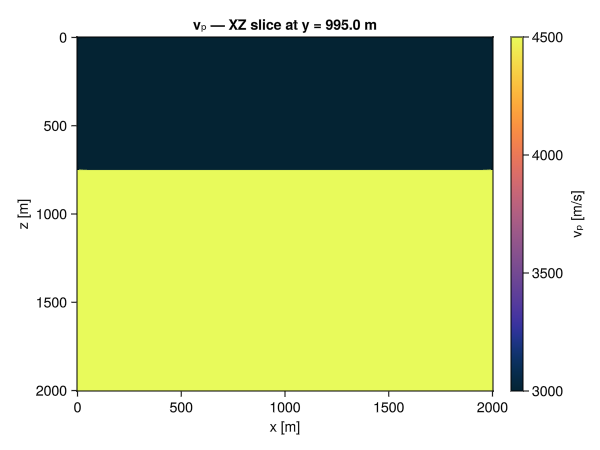

In [4]:
vp_xz = velmod[4, div(nx,2), :, :]   # XZ slice through y-centre

fig, ax, hm = heatmap(collect(xc), collect(zc), vp_xz,
    axis = (title = "vₚ — XZ slice at y = $(yc[div(ny,2)]) m",
            xlabel = "x [m]", ylabel = "z [m]", yreversed = true),
    colormap = :thermal)
Colorbar(fig[1,2], hm, label = "vₚ [m/s]")
fig

---
## 2  Simulation Configuration

All parameters are passed via `config_template_3d`, which validates inputs and returns a `Dict`.

### Key differences to 2D

| Topic | 2D | 3D |
|-------|----|----|
| Moment tensor | `Mxx`, `Mxz`, `Mzz` | full 6-component tensor |
| Snapshots | single XZ plane | XY, XZ, YZ planes per centre point |
| DAS | x- or z-aligned | x-, y-, or z-aligned |


In [ ]:
config = ElasticFDSG.config_template_3d(

    # ── Settings ──────────────────────────────────────────────────────────
    device    = "metal",          # cpu | metal | cuda | rocm | oneAPI
    precision = "Float32",        # Float32 | Float64
    fd_order  = 8,                # 1-10
    verbose   = true,             # print summary and progress
    output_file = joinpath(@__DIR__, "demo3d.h5"),

    # ── Time ──────────────────────────────────────────────────────────────
    t_start = 0.0,
    t_end   = 1.0,
    dt      = 0.0005,           # will be adjusted to satisfy CFL

    # ── Source ────────────────────────────────────────────────────────────
    fdom           = 40.0,      # dominant frequency [Hz]
    wavelet        = "ricker",
    wavelet_center = 0.05,      # centre time [s]; must be ≥ 1.25/fdom
    seismic_moment = 1e12,
    src_x = 1000.0, src_y = 1000.0, src_z = 500.0,

    # Double-couple moment tensor
    Mxx = -1.0, Mxy = 0.0, Mxz = 0.0,
    Myy =  0.0, Myz = 0.0, Mzz = 1.0,
    anisotropic = true,

    # ── Boundaries ────────────────────────────────────────────────────────
    xstart = "absorbing", xend = "absorbing",
    ystart = "absorbing", yend = "absorbing",
    zstart = "none",      zend = "absorbing",   # reflecting surface at top
    pml_layer = 10,

    # ── Receivers ─────────────────────────────────────────────────────────

    # Vertical geophone array at (x=100, y=500), receivers every 10 m in z
    geophones = [Dict("x" => 100.0, "y" => 500.0, "z" => Float64(z))
                 for z in 50.0:10.0:1950.0],

    das_x_aligned = [],   # no x-aligned DAS
    das_y_aligned = [],   # no y-aligned DAS
    das_z_aligned = [
        # vertical fiber co-located with geophones
        Dict("x"=>100.0, "y"=>500.0, "z"=>Dict("start"=>50.0,  "step"=>10.0, "end"=>1950.0)),
        # second vertical fiber at different x
        Dict("x"=>500.0, "y"=>500.0, "z"=>Dict("start"=>50.0,  "step"=>10.0, "end"=>1950.0)),
    ],

    # Snapshot planes — one entry produces XY, XZ, YZ slices through that point
    snapshot_positions = [
        Dict("x"=>1000.0, "y"=>1000.0, "z"=>500.0),   # centred on source
    ],
    snapshot_times  = collect(0.1:0.1:1.0),
    snapshot_fields = ["vx", "vy", "vz"],
);

--- 
## 3  Run the Simulation

`runsim` runs the forward solver and — because `output_file` is set — writes all results to an HDF5 file.
Pass `output_file = nothing` instead to get results directly as a Julia struct.
>  A 401³ grid takes some tome to compute on the CPU. For a speed boost, GPU is recommendet.



In [9]:
ElasticFDSG.runsim(config, velmod)

┌ Warning: Stiffness tensor violates C-PML stability at some grid points.
└ @ nothing nothing:nothing
┌ Warning: Given Δt=0.0005 does not satisfy the CFL criterion. Δt changed to 0.00034990927.
└ @ nothing nothing:nothing


┌────────────────────────────────────────────────────────────────────────────────
│  ElasticFDSG — 3D Simulation Summary
├────────────────────────────────────────────────────────────────────────────────
├── System
│    Device                     Apple M2 Max
│    Precision                  Float32
│    Est. Memory                3.95 GB
├────────────────────────────────────────────────────────────────────────────────
├── Grid
│    x (inner)                  0.0 : 5.00 : 2000.0  (n=401)
│    x (extended)               -90.0 : 5.00 : 2090.0  (n=437)
│    y (inner)                  0.0 : 5.00 : 2000.0  (n=401)
│    y (extended)               -90.0 : 5.00 : 2090.0  (n=437)
│    z (inner)                  0.0 : 5.00 : 2000.0  (n=401)
│    z (extended)               -40.0 : 5.00 : 2090.0  (n=427)
│    Total nodes                81543763
│    PML nodes                  9032050
│    PML sides                  xstart, xend, ystart, yend, zend
├───────────────────────────────────────────────────

Running solver... 100%|███████████████████| Time: 0:21:30 ( 0.45  s/it)


Results saved.


---
## 4  Load Results

`load_results` reads the HDF5 output into a nested Dict with the following top-level keys:

- `"time"` — time axis
- `"grid"` — spatial coordinates `x_coordinates`, `y_coordinates`, `z_coordinates`
- `"source"` — source time function and location
- `"geophones"` — per-receiver velocity time series (`geophone_1`, `geophone_2`, …)
- `"das"` — per-fiber data, grouped by orientation (`z_aligned → fiber_1`, `fiber_2`, …)
- `"snapshots"` — wavefield at requested times, grouped by plane (`plane_1 → XY_data`, `XZ_data`, `YZ_data`)

In [10]:
results   = ElasticFDSG.load_results(joinpath(@__DIR__, "demo3d.h5"))

grid      = results["grid"]
x_coords  = grid["x_coordinates"]
y_coords  = grid["y_coordinates"]
z_coords  = grid["z_coordinates"]
time      = results["time"]["time"]
snapshots = results["snapshots"]
geophones = results["geophones"]
das       = results["das"]

snap_times = snapshots["times"]
println("Loaded $(length(time)) time steps, $(length(snap_times)) snapshots")
println("Geophones: $(length(geophones))")
println("DAS z-aligned fibers: $(length(das["z_aligned"]))")

Loaded 2859 time steps, 10 snapshots
Geophones: 191
DAS z-aligned fibers: 2


---
## 5  Wavefield Snapshots

Each snapshot plane centre produces three 2D slices:
- `XY_data` — shape `(n_times, n_fields, nx, ny)`, slice at fixed z
- `XZ_data` — shape `(n_times, n_fields, nx, nz)`, slice at fixed y
- `YZ_data` — shape `(n_times, n_fields, ny, nz)`, slice at fixed x

We visualise the velocity magnitude $|\mathbf{v}| = \sqrt{v_x^2 + v_y^2 + v_z^2}$ on all three planes for a chosen snapshot time.

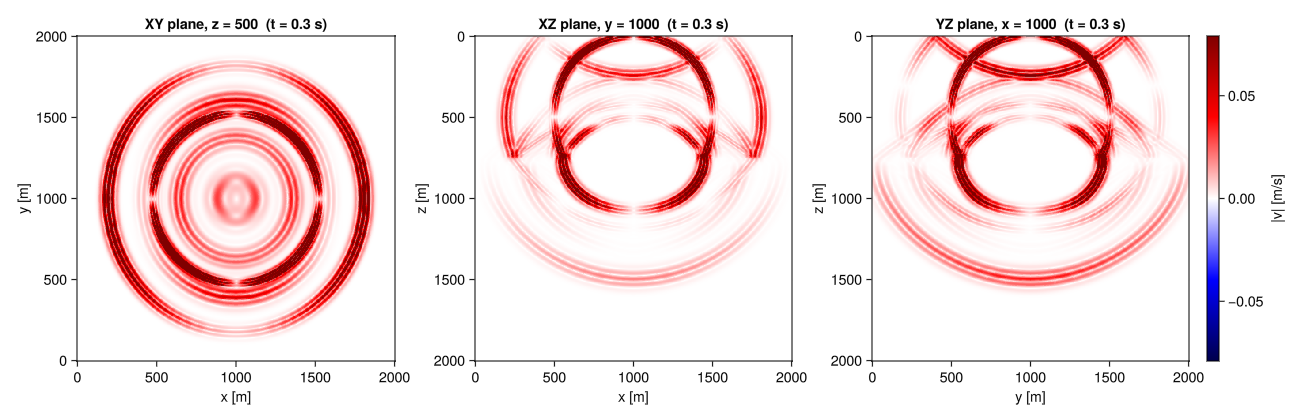

In [ ]:
tid = 3   # snapshot index to display

snap = snapshots["plane_1"]
XY   = snap["XY_data"][tid, :, :, :]   # (n_fields, nx, ny)
XZ   = snap["XZ_data"][tid, :, :, :]   # (n_fields, nx, nz)
YZ   = snap["YZ_data"][tid, :, :, :]   # (n_fields, ny, nz)

# velocity magnitude on each plane
vmag_xy = @. sqrt(XY[1,:,:]^2 + XY[2,:,:]^2 + XY[3,:,:]^2)
vmag_xz = @. sqrt(XZ[1,:,:]^2 + XZ[2,:,:]^2 + XZ[3,:,:]^2)
vmag_yz = @. sqrt(YZ[1,:,:]^2 + YZ[2,:,:]^2 + YZ[3,:,:]^2)

color_scale = 5
clim_xy = maximum(vmag_xy) / color_scale
clim_xz = maximum(vmag_xz) / color_scale
clim_yz = maximum(vmag_yz) / color_scale

fig = Figure(size = (1300, 420))
ax1 = Axis(fig[1,1], title="XY plane, z = 500  (t = $(round(snap_times[tid], digits=2)) s)",
           xlabel="x [m]", ylabel="y [m]")
ax2 = Axis(fig[1,2], title="XZ plane, y = 1000  (t = $(round(snap_times[tid], digits=2)) s)",
           xlabel="x [m]", ylabel="z [m]", yreversed=true)
ax3 = Axis(fig[1,3], title="YZ plane, x = 1000  (t = $(round(snap_times[tid], digits=2)) s)",
           xlabel="y [m]", ylabel="z [m]", yreversed=true)

hm1 = heatmap!(ax1, x_coords, y_coords, vmag_xy;
               colormap=:seismic, colorrange=(-clim_xy, clim_xy))
hm2 = heatmap!(ax2, x_coords, z_coords, vmag_xz;
               colormap=:seismic, colorrange=(-clim_xz, clim_xz))
hm3 = heatmap!(ax3, y_coords, z_coords, vmag_yz;
               colormap=:seismic, colorrange=(-clim_yz, clim_yz))

Colorbar(fig[1,4], hm3, label="|v| [m/s]")
fig

# NOTE: XY-plane contains reflections (in the middle) from the layer interface.

---
## 6  Geophone Records

The vertical array runs at `(x=100, y=500)` from z = 50 m to z = 1950 m (10 m spacing).
Each receiver records three components $v_x$, $v_y$, $v_z$.
Traces are normalised per receiver to `[−1, 1]` for display.

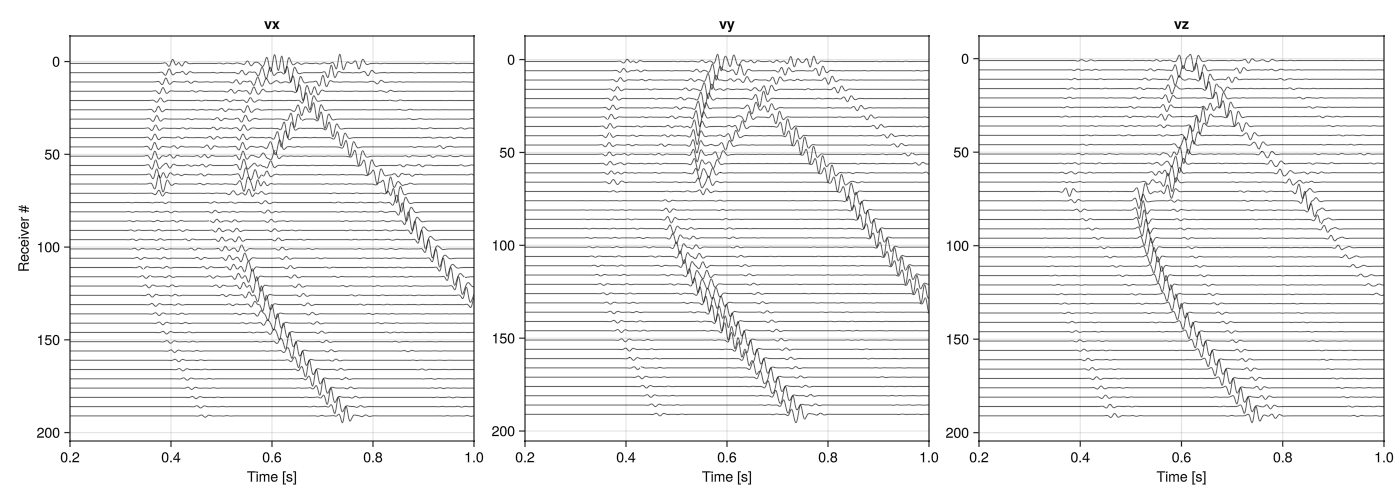

In [22]:
norm11(arr) = arr ./ maximum(abs, arr)
amplitude_scale = 5
n_geo = length(geophones)

fig = Figure(size=(1400, 500))
ax1 = Axis(fig[1,1], yreversed=true, title="vx", xlabel="Time [s]", ylabel="Receiver #")
ax2 = Axis(fig[1,2], yreversed=true, title="vy", xlabel="Time [s]")
ax3 = Axis(fig[1,3], yreversed=true, title="vz", xlabel="Time [s]")

for g in 1:5:n_geo   # plot every 5th receiver to keep it readable
    d = geophones["geophone_$(g)"]["data"]   # shape: (3, n_time)
    lines!(ax1, time, norm11(d[1,:]) .* amplitude_scale .+ g, color=:black, linewidth=0.6)
    lines!(ax2, time, norm11(d[2,:]) .* amplitude_scale .+ g, color=:black, linewidth=0.6)
    lines!(ax3, time, norm11(d[3,:]) .* amplitude_scale .+ g, color=:black, linewidth=0.6)
end

for ax in (ax1, ax2, ax3)
    xlims!(ax, 0.2, maximum(time))
end
fig

---
## 7  DAS Fiber Data

Both z-aligned fibers run from z = 50 m to z = 1950 m (10 m channel spacing).
They record axial strain along the z-axis.

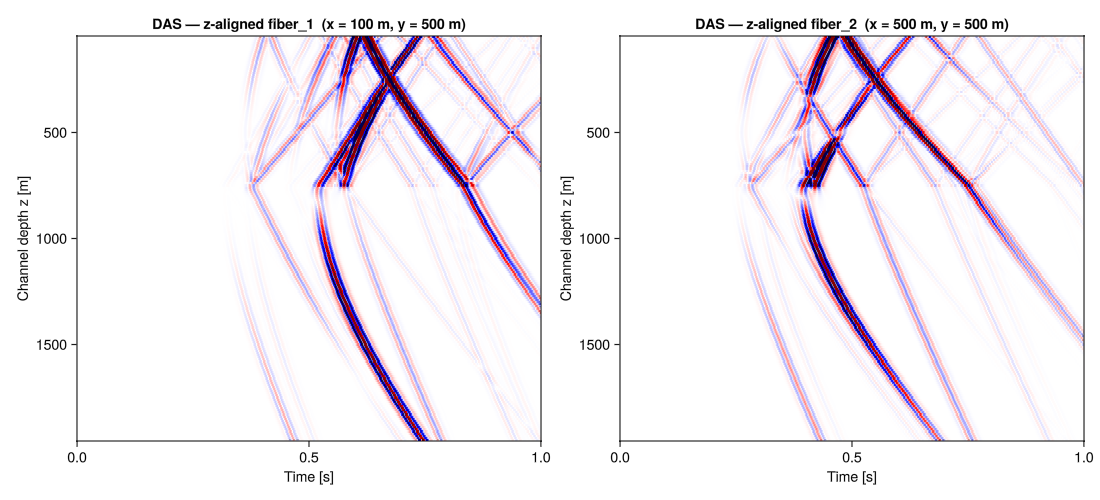

In [24]:
fig = Figure(size=(1100, 500))

for (i, fiber_key) in enumerate(("fiber_1", "fiber_2"))
    fiber     = das["z_aligned"][fiber_key]
    data      = fiber["data"]                 # shape: (n_channels, n_time)
    loc       = fiber["location"]             # shape: (3, n_channels)
    z_channel = loc[3, :]

    clim = maximum(abs, data) / 5

    ax = Axis(fig[1, i],
        title    = "DAS — z-aligned $(fiber_key)  (x = $(Int(loc[1,1])) m, y = $(Int(loc[2,1])) m)",
        xlabel   = "Time [s]",
        ylabel   = "Channel depth z [m]",
        yreversed = true)

    hm = heatmap!(ax, time, z_channel, transpose(data);
                  colormap=:seismic, colorrange=(-clim, clim))
end

fig